# MScFE 622 Stochastic Modeling - Group Work Project #2
## Step 1 - Data Preparation and Exploration

This notebook is the canonical technical analysis artifact. Step 1 constructs the maximum common daily sample for TLT, GLD, SPY, and VIX, reports the required ETF log returns and VIX first differences, and visualizes both series groups. Numerical results below are produced from the committed canonical Step 1 dataset; no values are estimated manually.

### Data source and financial interpretation

The project pipeline downloads daily Yahoo Finance **Adjusted Close** series for TLT, GLD, and SPY and the Yahoo Finance VIX series (`^VIX`), then retains dates on which all four prices are present. The VIX Index is designed as a forward-looking, approximately 30-day measure of expected S&P 500 volatility inferred from SPX option quotations (Cboe Global Markets). Whaley likewise describes the VIX as an option-market volatility benchmark and explains its financial interpretation (Whaley 98-105).

<!-- citekey: cboe2019vixfaq -->
<!-- citekey: whaley2009vix -->

**Source note.** Market observations: Yahoo Finance, downloaded by the project loader required by the assignment. VIX interpretation: Cboe Global Markets and Whaley (2009). Calculations and figures: project team.

In [1]:
from vix_regime_allocation import notebook_helpers as nb


In [2]:
nb.data_source_and_financial_interpretation_002()


,TLT,GLD,SPY,VIX,TLT_log_return,GLD_log_return,SPY_log_return,VIX_change
Date,,,,,,,,
2004-11-19,43.302605,44.779999,78.858780,13.50,-0.008012,0.008973,-0.011178,0.520000
2004-11-22,43.528297,44.950001,79.234833,12.97,0.005198,0.003789,0.004757,-0.530000
2004-11-23,43.582287,44.750000,79.355743,12.67,0.001240,-0.004459,0.001525,-0.300000
2004-11-24,43.582287,45.049999,79.543793,12.72,0.000000,0.006682,0.002367,0.050000
2004-11-26,43.297714,45.290001,79.483330,12.78,-0.006551,0.005313,-0.000760,0.059999


In [3]:
nb.data_source_and_financial_interpretation_003()


,value
start_date,2004-11-19
end_date,2026-08-17
observations,5465
missing_values,0


### ETF daily log returns

For ETF $i$ on trading row $t$, Step 1 uses the daily log return

$$
r_{i,t}=\ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right),
$$

where $P_{i,t}$ is the adjusted close for ETF $i$ at row $t$. Missing common dates are removed **before** this lag is formed; there is no filling or interpolation. The first row is then removed because it has no preceding common-sample observation.

### Daily change in VIX

**Greek letter used below:** $\Delta$ - **delta**, pronounced *DEL-tuh*, meaning a finite change or difference.

The Step 1 VIX observation is the first difference

$$
\Delta VIX_t = VIX_t - VIX_{t-1}.
$$

This is a level change, not a percentage return. It measures how the option-implied volatility index changed between consecutive rows of the common sample.

In [4]:
nb.daily_change_in_vix_006()


,count,mean,std,min,25%,50%,75%,max
TLT_log_return,5465.0,0.000114,0.009156,-0.069011,-0.005299,0.000432,0.005458,0.072503
GLD_log_return,5465.0,0.000405,0.011492,-0.108412,-0.005154,0.000590,0.006348,0.106974
SPY_log_return,5465.0,0.000416,0.011904,-0.115887,-0.003935,0.000718,0.005781,0.135577
VIX_change,5465.0,0.000404,1.901620,-18.710003,-0.720000,-0.099999,0.570000,24.860001


In [5]:
nb.daily_change_in_vix_007()


**Computed Step 1 observations.** The common sample contains **5465** rows from **2004-11-19** through **2026-08-17**. The largest absolute daily VIX change occurs on **2020-03-16** and equals **24.86000061035156** VIX points. Among the three ETF log-return series, **SPY_log_return** has the largest sample daily standard deviation, **0.011904140971138589**, using `ddof=1`.

### Required ETF-return figure

The next cell calls the shared project plotting function rather than recreating plotting logic inside the notebook.

**Source note.** Yahoo Finance adjusted-close observations; project-team log-return calculations and visualization.

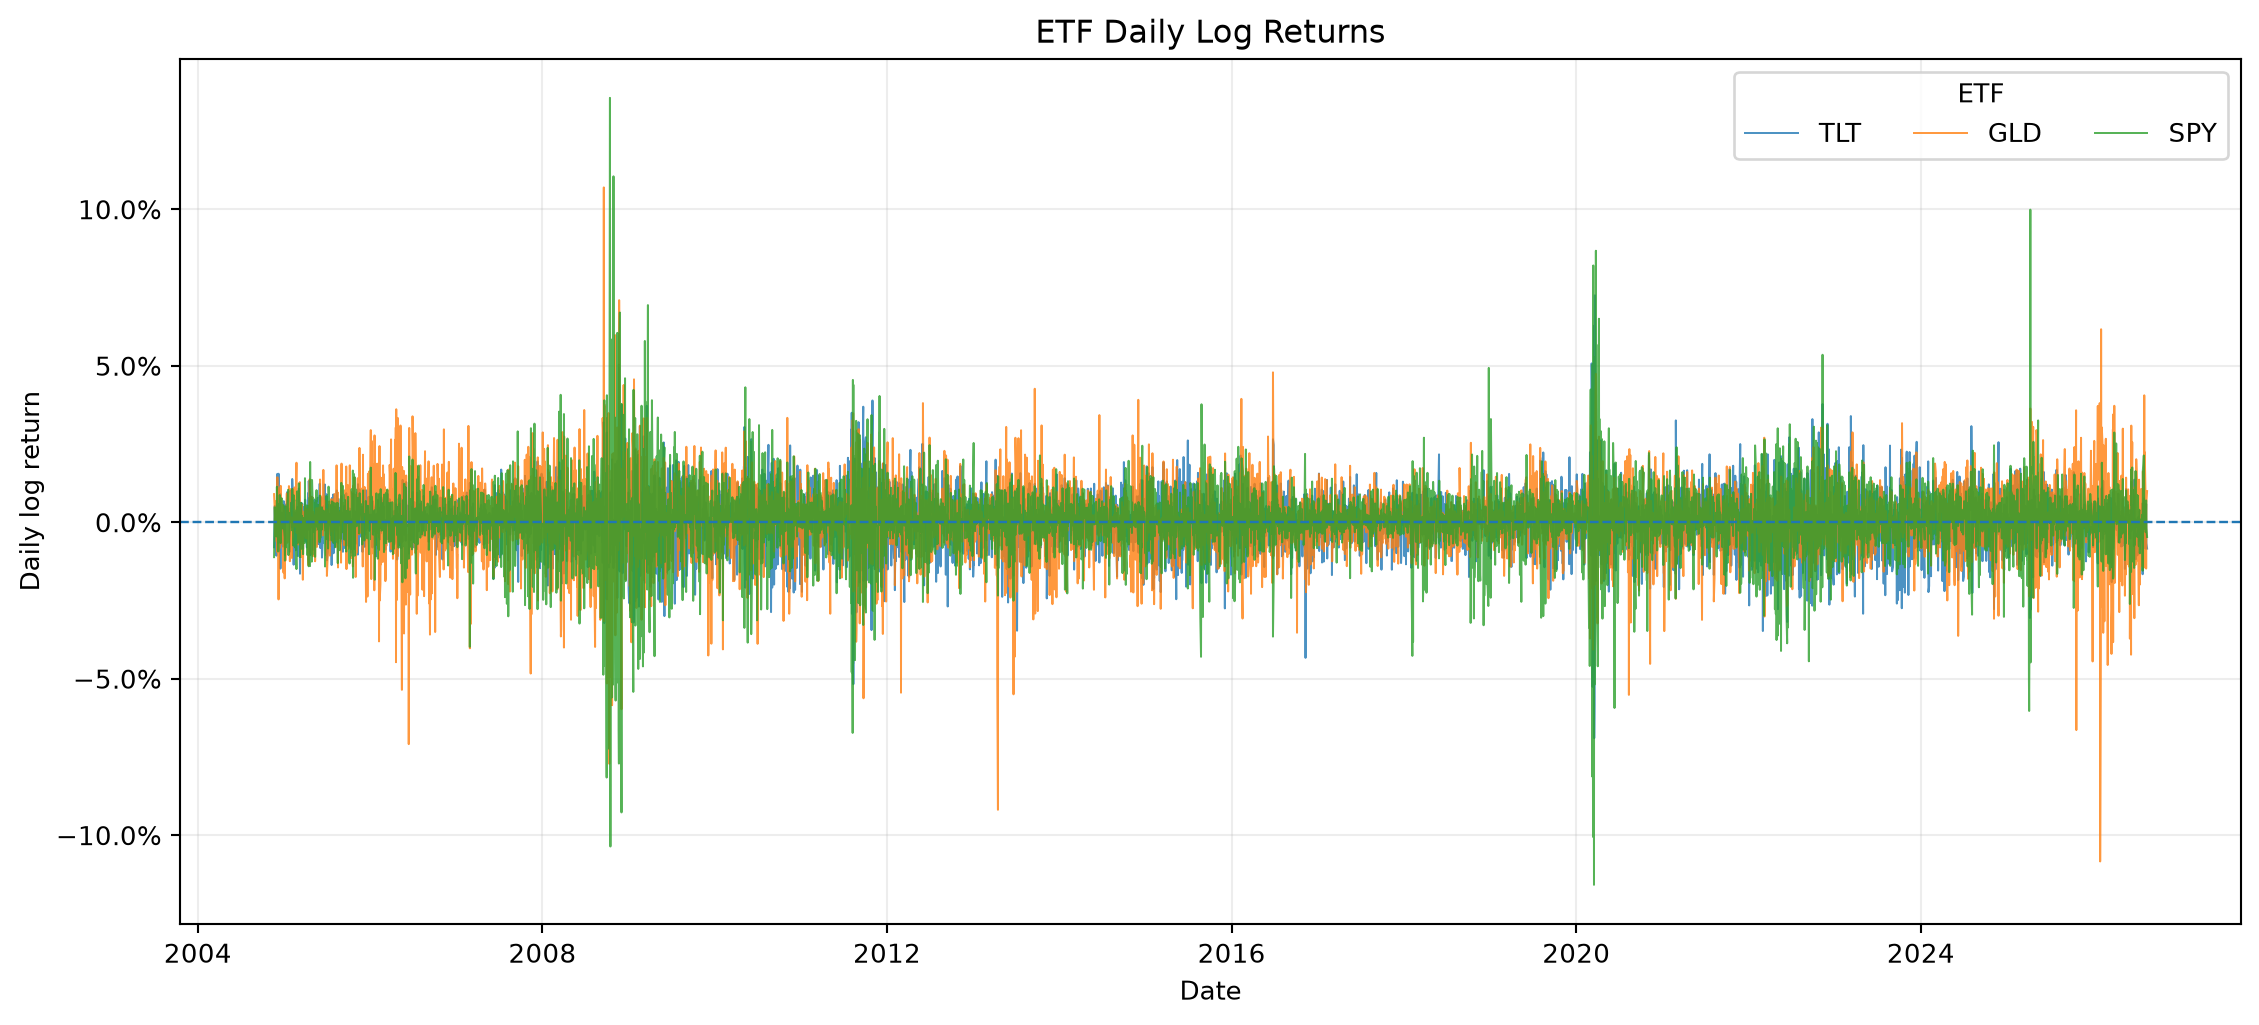

In [6]:
nb.required_etf_return_figure_009()


### Required VIX-change figure

The plot shows the first difference of the VIX level. Positive observations indicate an increase in the index from the preceding common-sample row, while negative observations indicate a decrease. This sign interpretation follows directly from the Step 1 difference definition and is not a directional forecast for SPY.

**Source note.** Yahoo Finance VIX observations; project-team first-difference calculations and visualization. VIX financial interpretation follows Cboe Global Markets and Whaley (2009).

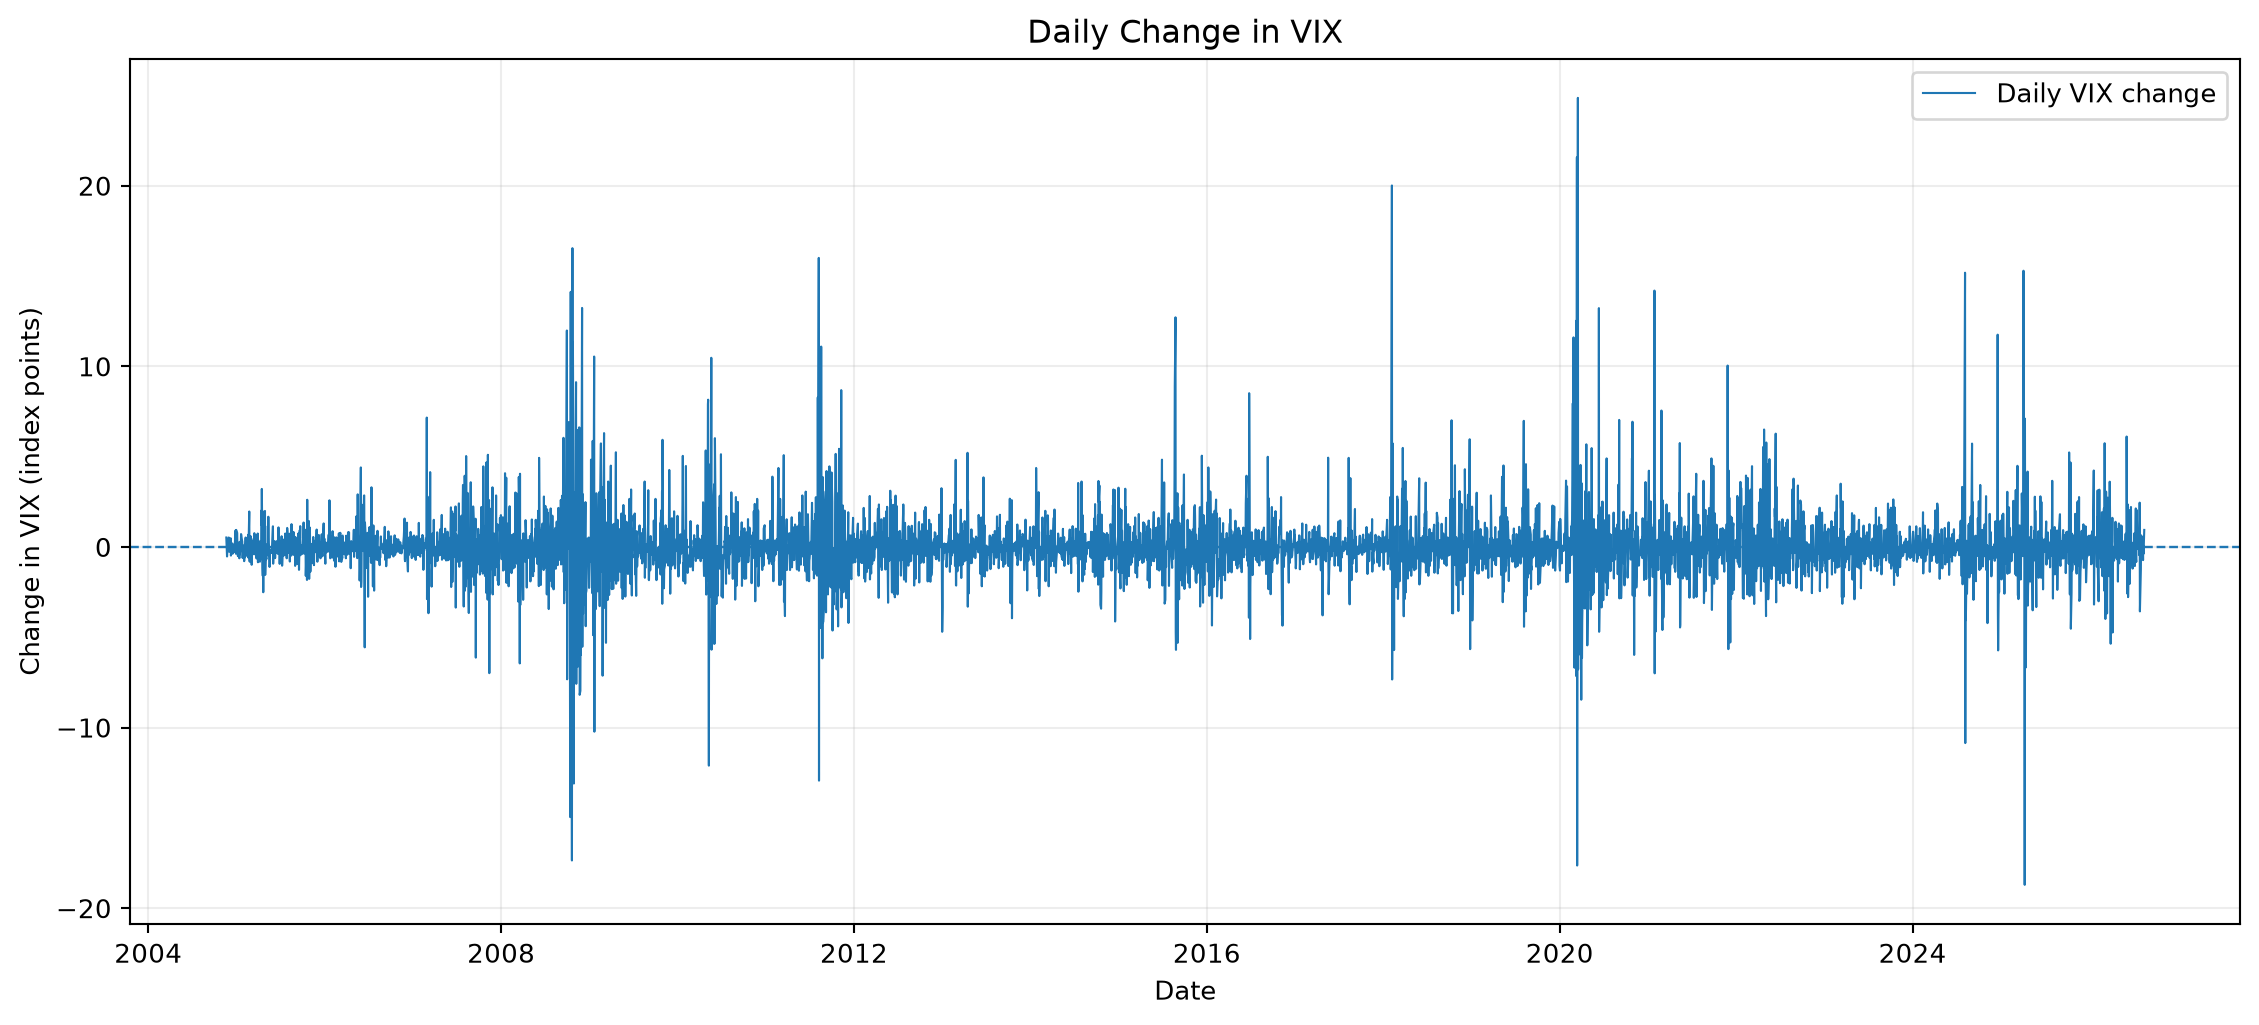

In [7]:
nb.required_vix_change_figure_011()


### Interpretation, assumptions, and limitations

Step 1 is deliberately descriptive. The ETF panels reveal when daily log-return fluctuations cluster or spike, while the VIX-change panel reveals when option-implied volatility moves sharply between common-sample rows. The computed statistics above quantify the sample span, the largest observed absolute VIX movement, and the relative daily dispersion of the three ETF return series without introducing a regime model.

Key assumptions and limitations are: (1) the analysis uses the Yahoo Finance fields returned by the specified loader; (2) only the maximum **common** dates are retained, so observations missing for any one series are removed before lags; (3) there is no interpolation or forward fill; (4) `VIX_change` is an arithmetic first difference in VIX points, not a VIX return; (5) Step 1 contains no causal, predictive, or out-of-sample claim; and (6) later Step 2 regime models must treat this cleaned dataset as their canonical input rather than constructing a different sample.

## Step 2 - Modeling VIX Regimes: Discrete Markov Chains

Step 2 first treats the observed daily change in the VIX as a discretized state variable. The input is **only** the committed `VIX_change` series from Step 1; no live data are downloaded and no VIX-level thresholds are used. For each requested state count, the empirical distribution of daily VIX changes is divided by linear quantiles. Observations exactly equal to an interior cut are assigned to the higher-numbered state. This produces an observable finite-state Markov-chain representation whose transition probabilities are estimated from consecutive state counts. The general finite-state transition framework and likelihood treatment are standard Markov-chain constructions; Baum et al. provide a classical statistical treatment of probabilistic functions of Markov chains (Baum et al. 164-171).

<!-- citekey: baum1970maximization -->

**Greek letter used below:** π — *pi*, pronounced “pie”.

For states $i,j\in\{0,\ldots,K-1\}$, the estimated transition probability is

$$
P_{ij}=\Pr(S_{t+1}=j\mid S_t=i)=rac{N_{ij}}{\sum_j N_{ij}},
$$

with no pseudocount or smoothing. A stationary distribution satisfies

$$
\pi=\pi P,\qquad \sum_i\pi_i=1.
$$

The project estimates both $K=2$ and $K=3$. State numbers are ordered by increasingly positive `VIX_change`: State 0 contains the lower changes, while the highest-numbered state contains the larger positive changes. These labels describe **changes in implied volatility**, not low/high VIX levels themselves.

**Source note.** Market observations and `VIX_change`: Step 1 project data derived from Yahoo Finance. Markov-chain methodology: Baum et al. (1970). Quantile discretization, calculations, tables, and figure: project team.

### Markov candidate: K=2

**Quantile intervals**

,state,lower_bound,upper_bound
0,0,-inf,-0.099999
1,1,-0.099999,inf


**Transition matrix**

,state_0,state_1
from_state,,
0,0.479266,0.520734
1,0.518072,0.481928


...

**Transition matrix**

,state_0,state_1,state_2
from_state,,,
0,0.349311,0.300826,0.349862
1,0.233132,0.431706,0.335162
2,0.414020,0.268346,0.317634


**Stationary distribution**

,stationary_probability
state,
0,0.332174
1,0.333638
2,0.334187


,value
conditional_log_likelihood,-5913.883847
transition_observations,5464.000000
free_transition_parameters,6.000000


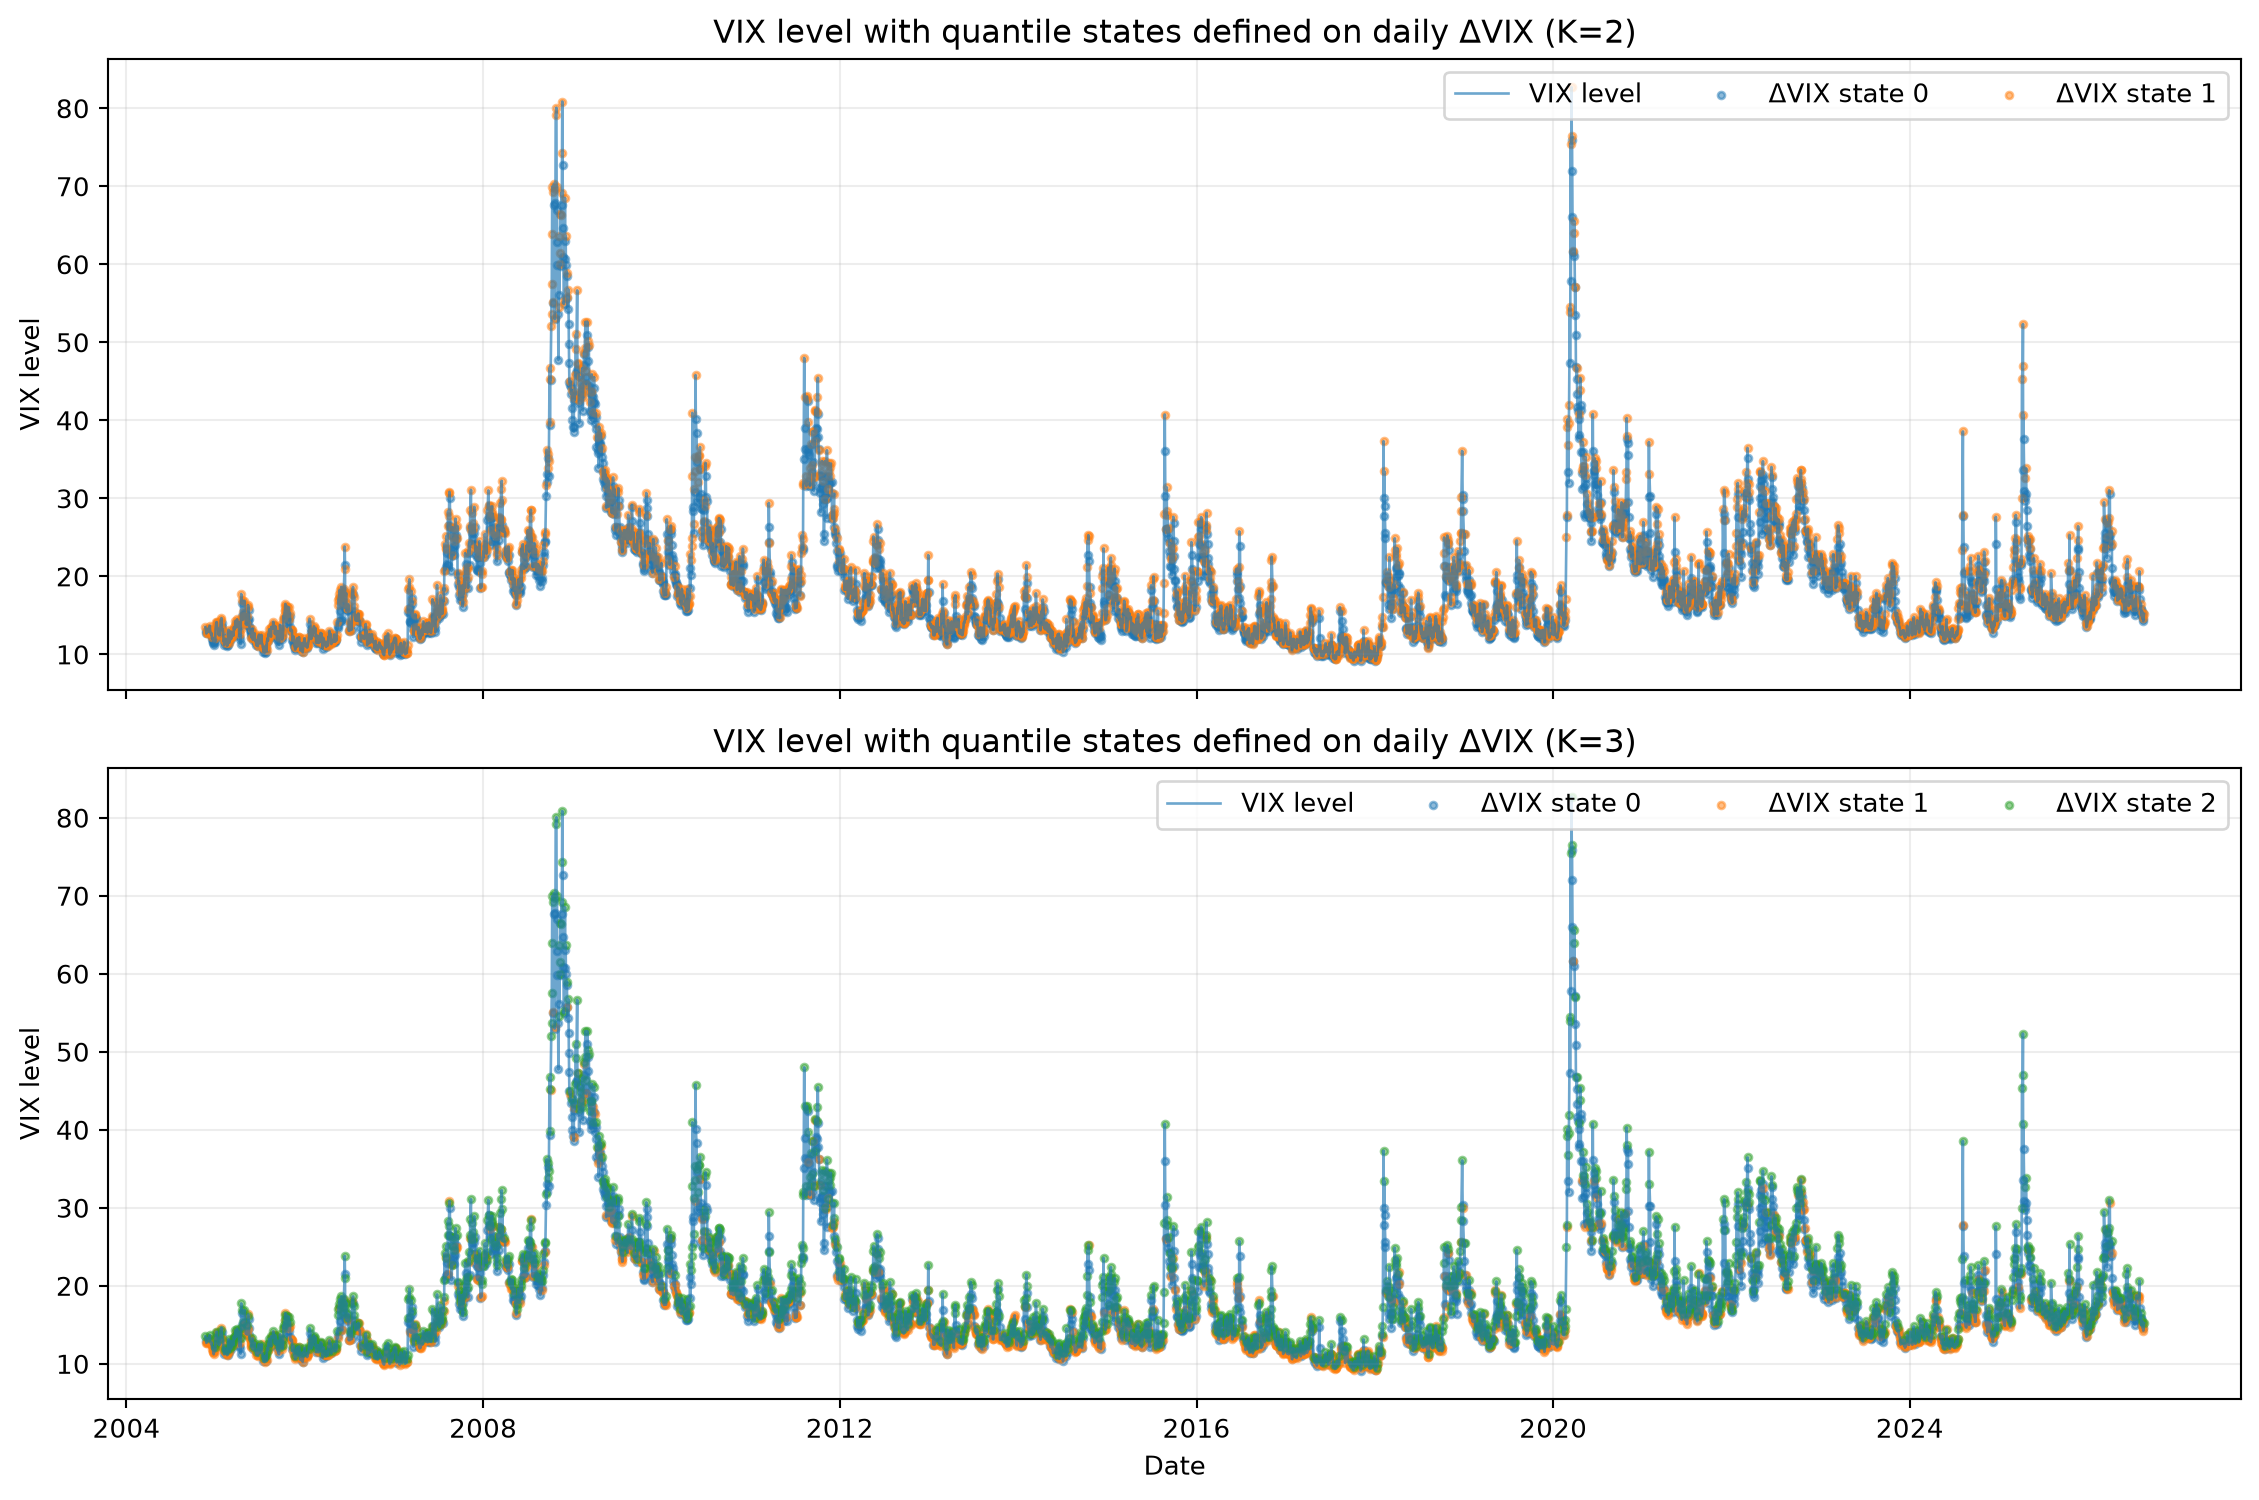

In [8]:
nb.step_2_modeling_vix_regimes_discrete_markov_chai_014()


### Markov-state interpretation and limitations

The two-state specification separates below-median from at-or-above-median daily VIX changes; the three-state specification provides a lower, middle, and upper quantile partition. The transition matrices therefore answer a conditional-frequency question: given today's observed VIX-change state, how often did the next trading observation fall into each state in this sample? The stationary distributions summarize the long-run probabilities implied by the fitted transition matrices, provided the estimated chain has a unique stationary distribution.

The figure deliberately plots the **VIX level** while coloring observations by states inferred from **daily VIX changes**. A high VIX level can occur in a negative-change state when volatility is falling, and a low VIX level can occur in a positive-change state when volatility is rising. For that reason, the numerical labels are retained rather than assigning unsupported names such as “calm” or “crisis.”

This construction is descriptive and full-sample. Quantile thresholds are estimated from the full Step 1 sample, the Markov property is an imposed approximation, discretization discards within-state variation, and transition probabilities are assumed time-homogeneous over the sample. Step 3 will compare the two state counts within the Markov family rather than selecting one here.

**Source note.** Interpretation of the fitted sample objects and limitations: project team; finite-state Markov methodology: Baum et al. (1970).

<!-- citekey: baum1970maximization -->

## Step 2 - Modeling VIX Regimes: Gaussian Hidden Markov Models

The second Step 2 specification treats the regime as an **unobserved** finite-state process and models the observed daily `VIX_change` conditional on that latent state with a Gaussian distribution. Hidden Markov models combine a Markov transition law for the latent state with state-conditional observation distributions; the standard likelihood and forward-backward framework is reviewed by Rabiner (257-286), while Baum et al. provide the classical likelihood-maximization foundation used by the EM family of procedures (Baum et al. 164-171; Rabiner 257-286).

<!-- citekey: baum1970maximization -->
<!-- citekey: rabiner1989tutorial -->

**Greek letters used in the emission equation:** μ — *mu*, pronounced “mew”; σ — *sigma*, pronounced “SIG-muh”.

For state $k$, the univariate Gaussian emission model is

$$
X_t\mid S_t=k \sim \mathcal{N}(\mu_k,\sigma_k^2),\qquad X_t=\Delta VIX_t.
$$

The implementation fits both $K=2$ and $K=3$ using five deterministic restarts with seeds 42-46, a diagonal covariance representation, at most 500 EM iterations, convergence tolerance $10^{-6}$, and minimum covariance $10^{-6}$. Only converged finite-likelihood restarts are eligible; the highest log-likelihood fit is retained, with the lower seed breaking an effectively exact likelihood tie. After fitting, every state-dependent output is relabeled by increasing fitted mean `VIX_change`, so State 0 has the lowest fitted conditional mean and the highest-numbered state has the highest fitted conditional mean.

The most-likely full-sample state path is decoded with the Viterbi algorithm, whose dynamic-programming origin is Viterbi's decoding work; smoothed posterior state probabilities are also retained for every observation (Viterbi 260-269; Rabiner 257-286).

<!-- citekey: viterbi1967decoding -->

**Source note.** Market observations and `VIX_change`: Step 1 project data derived from Yahoo Finance. HMM/EM/smoothing methodology: Baum et al. (1970) and Rabiner (1989); most-likely path decoding: Viterbi (1967). Model fitting, state relabeling, tables, diagnostics, and figures: project team.

### Gaussian HMM candidate: K=2

**Fitted and decoded state parameters**

,state,mean_vix_change,variance_vix_change,start_probability,viterbi_observations,viterbi_occupancy,posterior_mean_probability
0,0,-0.074387,0.654348,1.000000e+00,4159,0.761025,0.739429
1,1,0.212640,11.957452,1.034965e-36,1306,0.238975,0.260571


**Transition matrix**

,state_0,state_1
from_state,,
0,0.958717,0.041283
1,0.117102,0.882898


...

**Fitted and decoded state parameters**

,state,mean_vix_change,variance_vix_change,start_probability,viterbi_observations,viterbi_occupancy,posterior_mean_probability
0,0,-0.062142,0.384075,1.000000e+00,2900,0.530650,0.521821
1,1,-0.011439,3.118842,9.246767e-101,2306,0.421958,0.421097
2,2,0.659519,36.347398,3.003336e-208,259,0.047392,0.057082


**Transition matrix**

,state_0,state_1,state_2
from_state,,,
0,9.388732e-01,0.059776,0.001351
1,7.568002e-02,0.908619,0.015701
2,1.193886e-23,0.128159,0.871841


,value
selected_restart_seed,46
converged,True
log_likelihood,-8959.534974
observations,5465
free_parameters,14


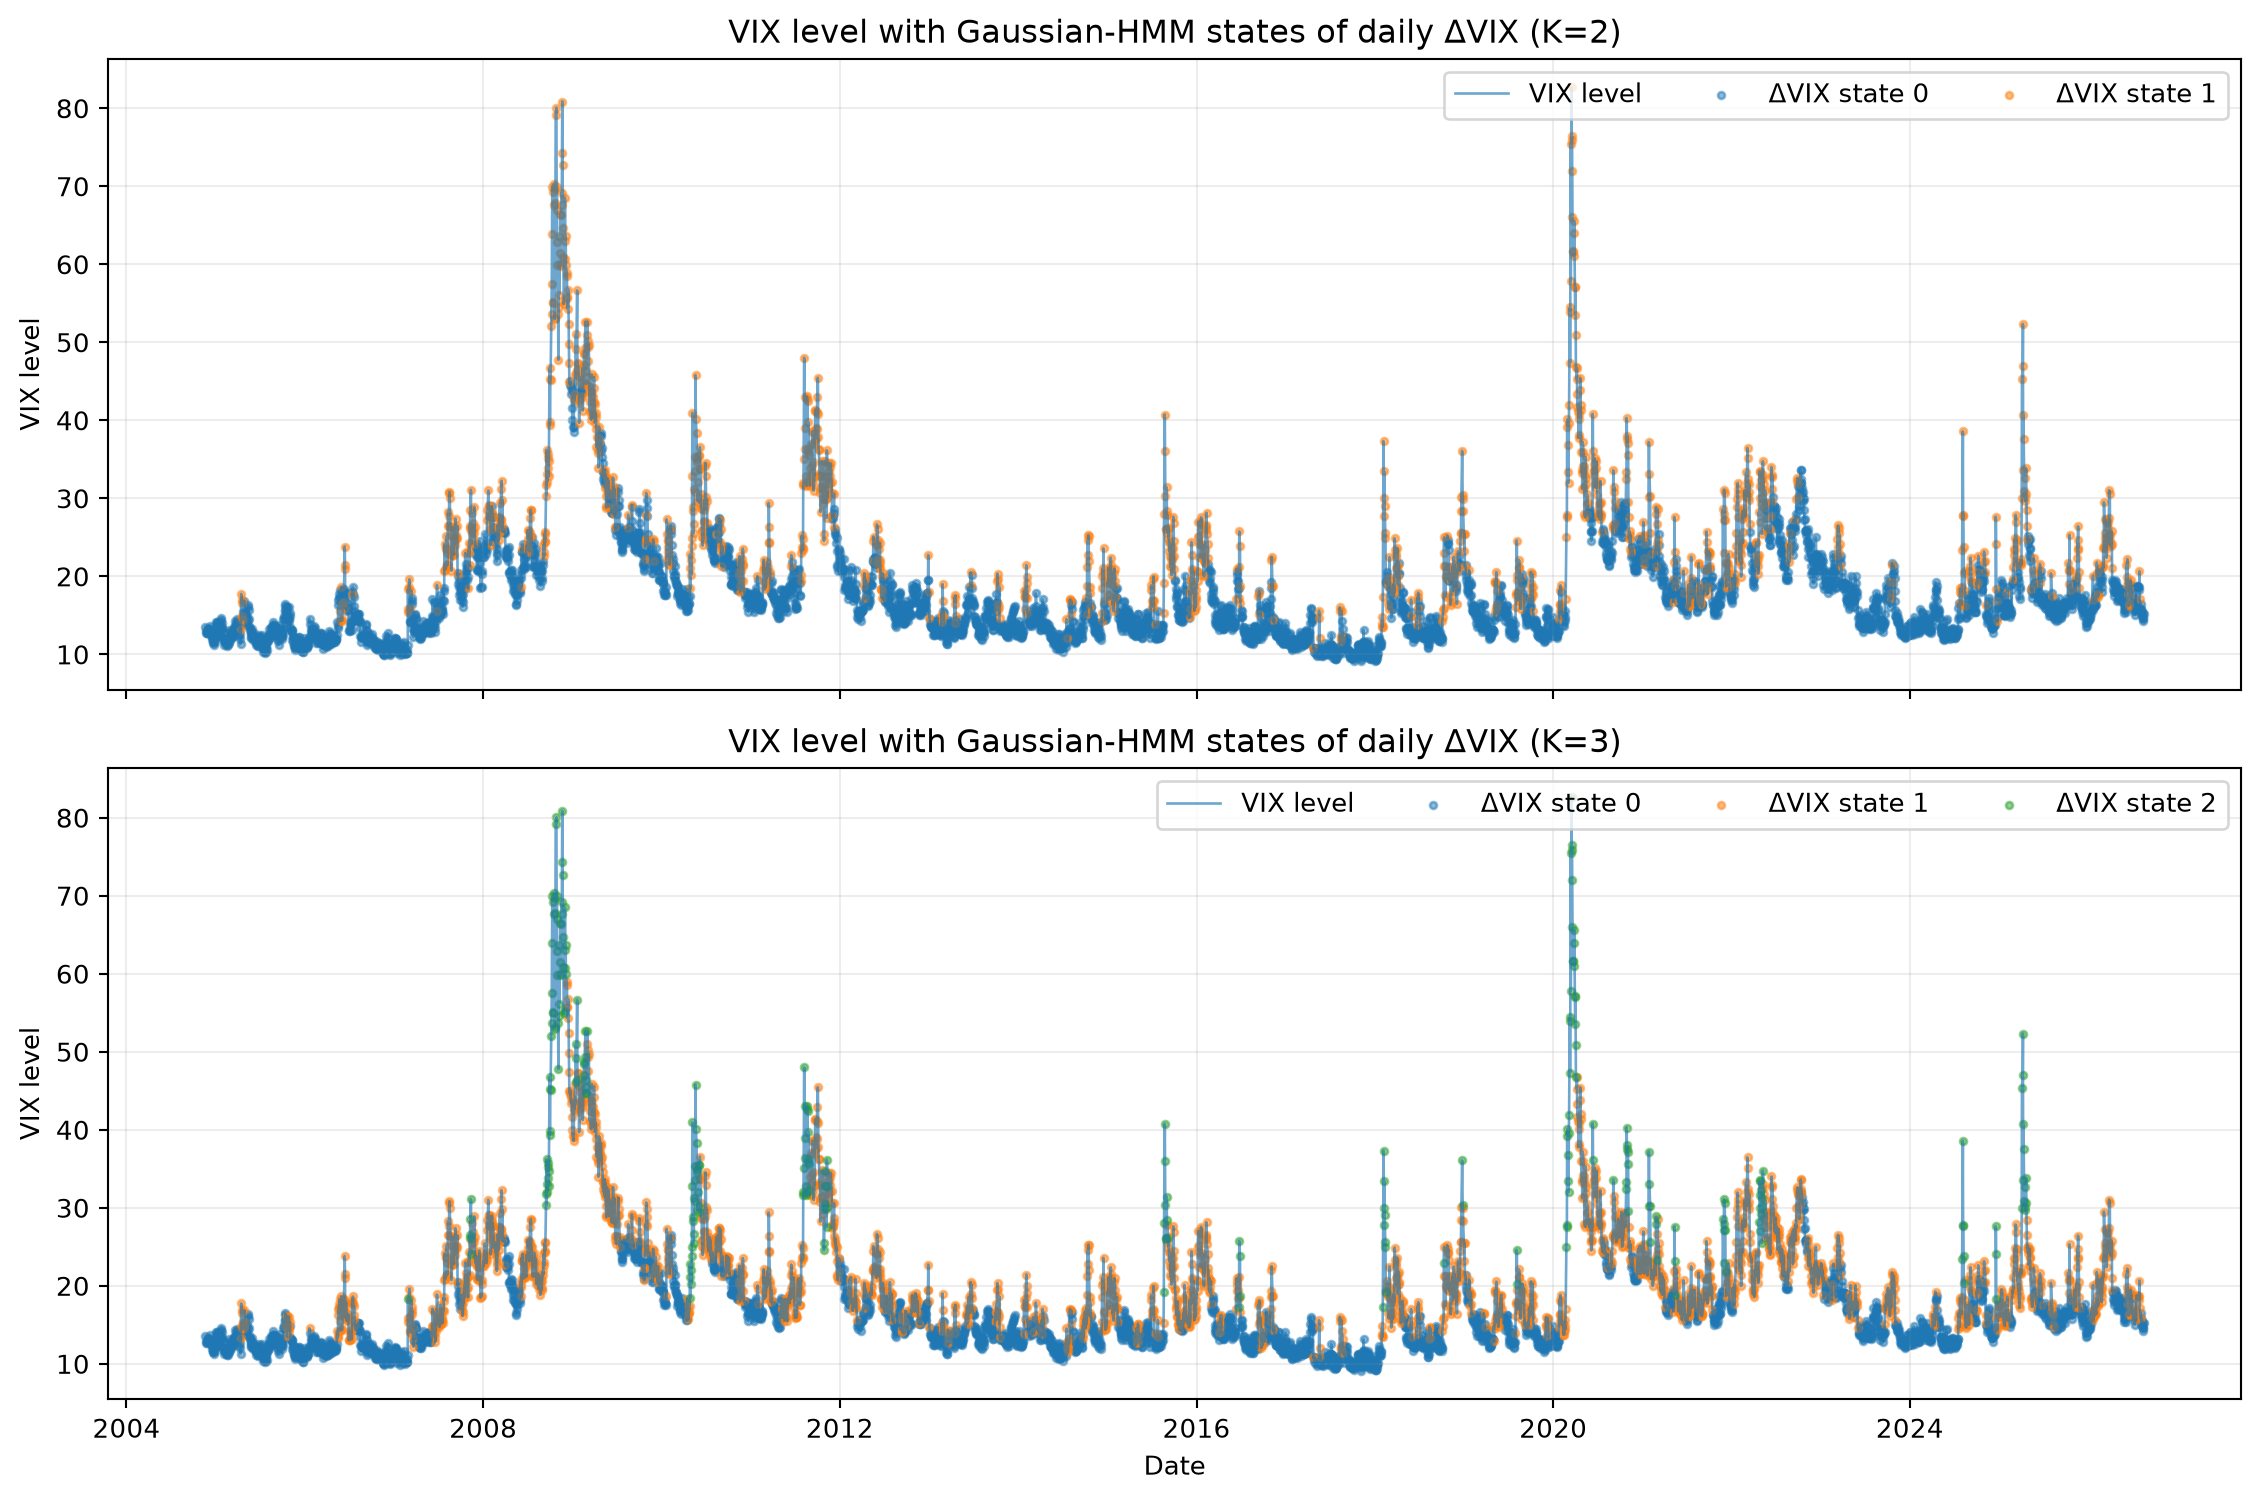

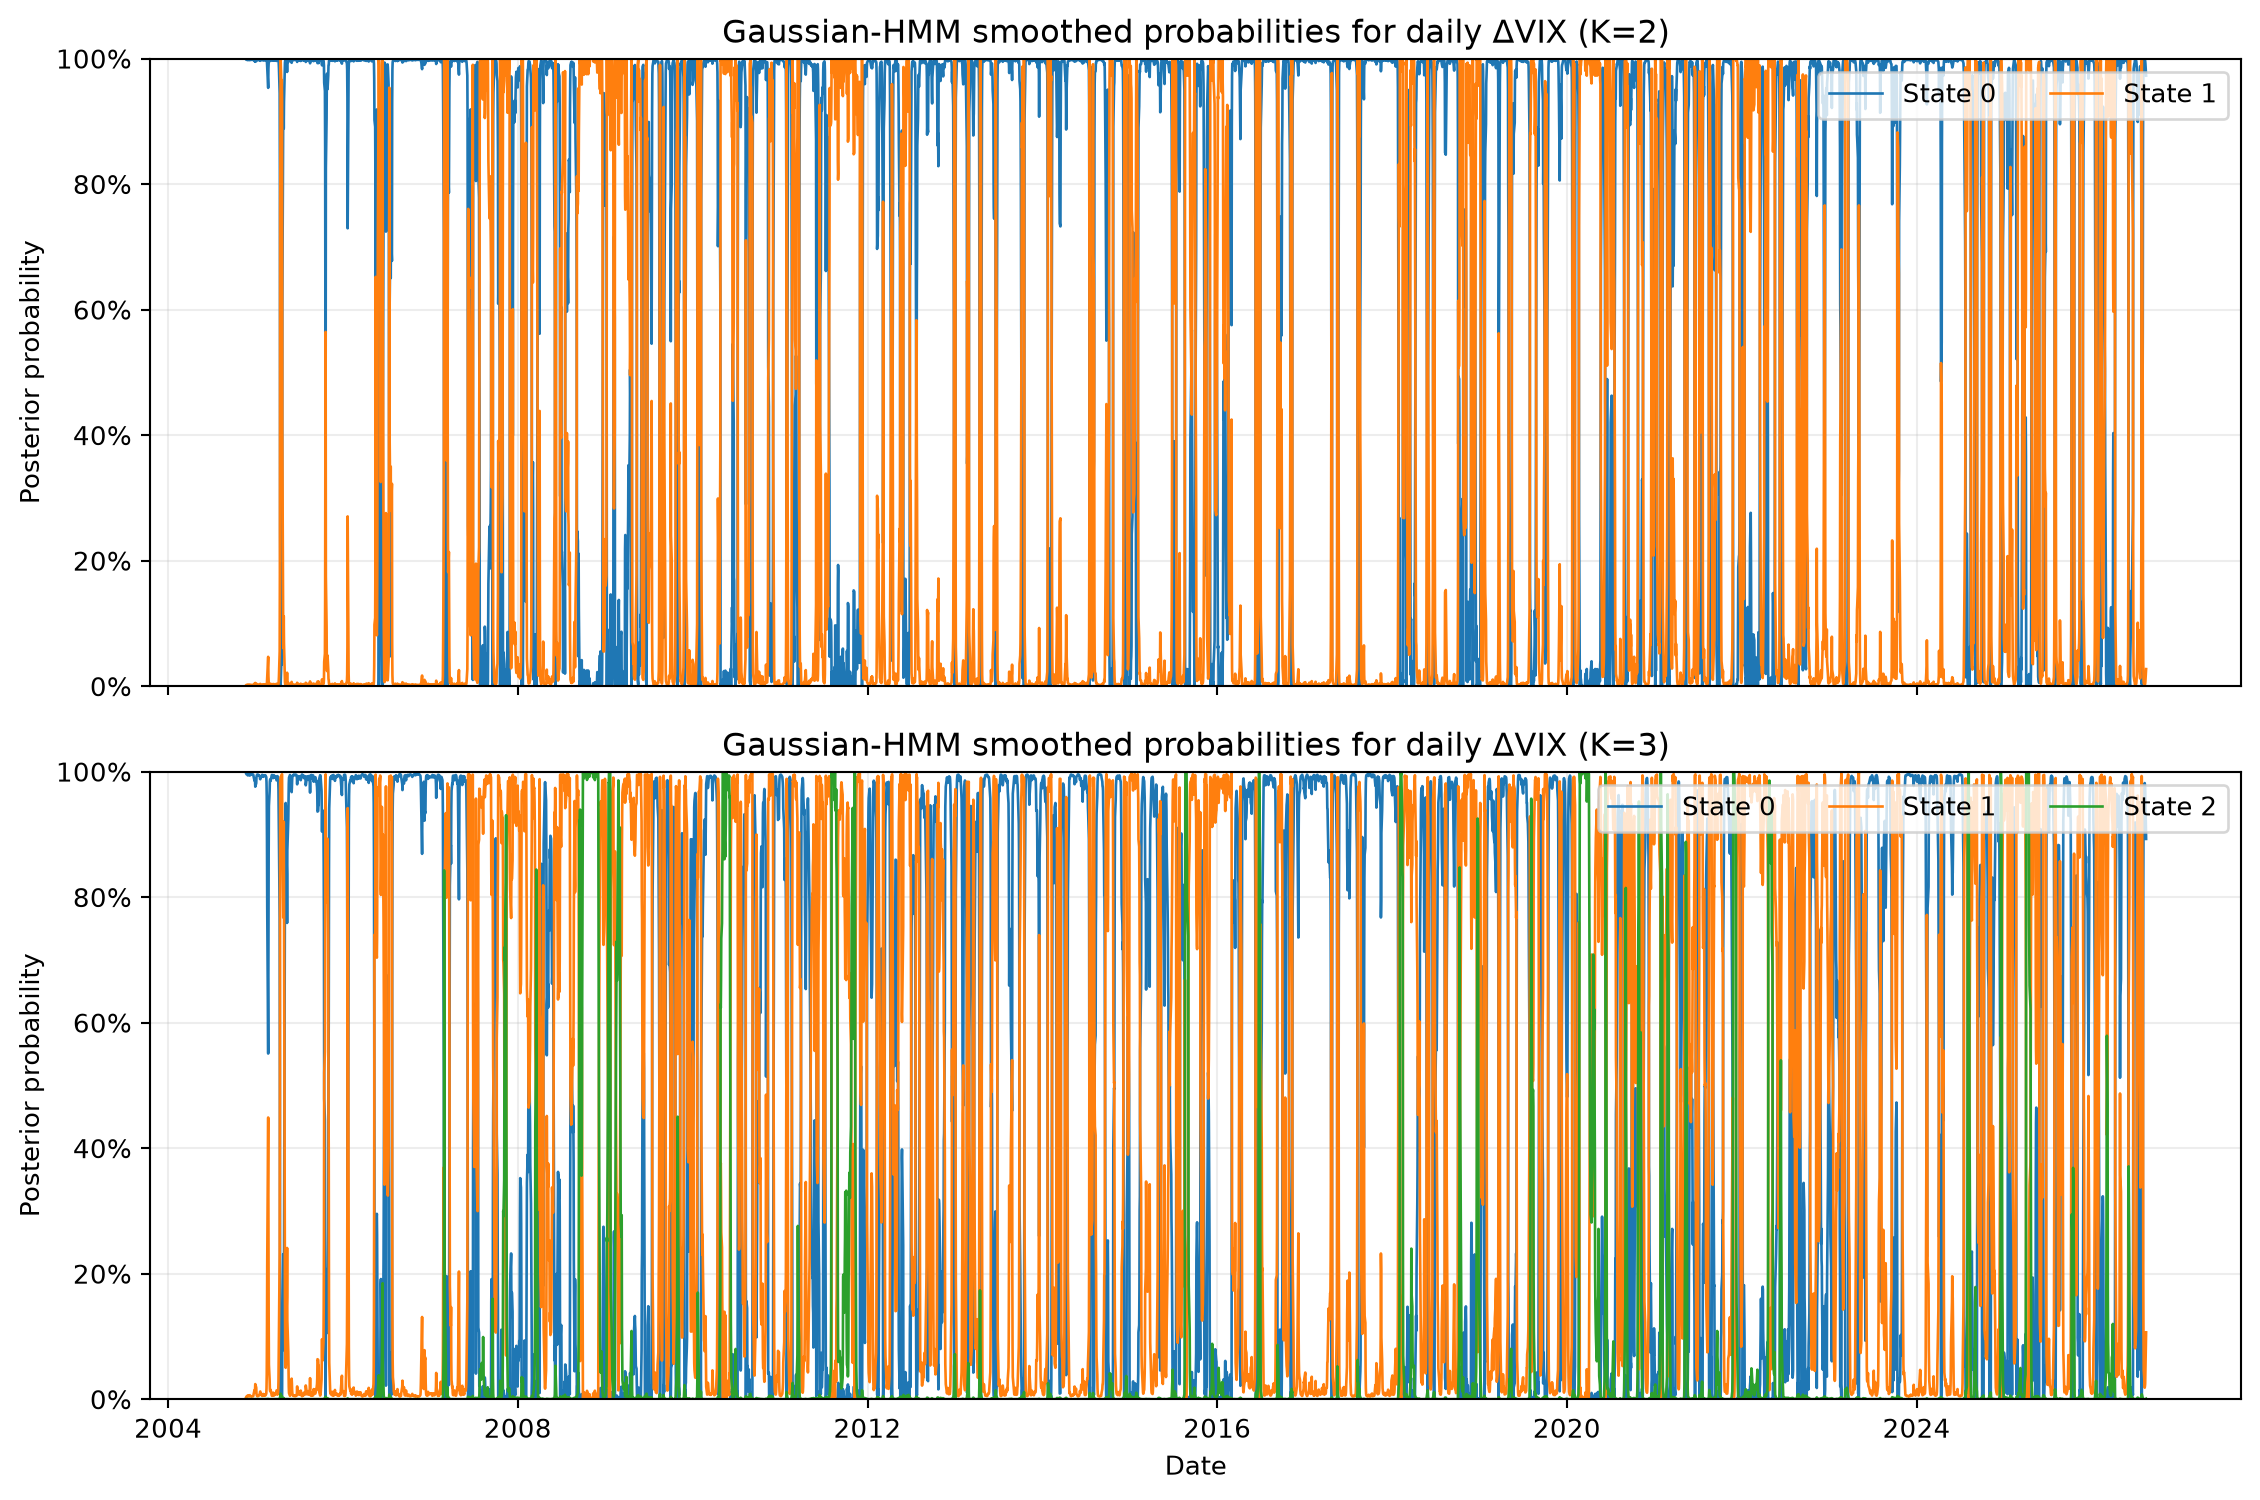

In [9]:
nb.step_2_modeling_vix_regimes_gaussian_hidden_mark_017()


### HMM-state interpretation and limitations

The fitted HMM states are ordered by their **conditional mean daily VIX change**, not by the contemporaneous VIX level. Consequently, a state with a positive fitted mean is evidence for a regime in which VIX changes tend to be upward on average; it is not automatically a “high-VIX,” “crisis,” or “fear” state. The parameter tables therefore retain neutral numeric labels and report both the decoded-state occupancy and the average posterior probability assigned to each state.

The VIX-state figure shows the observed VIX level colored by the Viterbi path, while the probability figure displays the smoothed posterior probabilities. A sharp switch in the decoded path should be interpreted together with the posterior probabilities: diffuse probabilities indicate state uncertainty even when the Viterbi decoder must choose a single state.

The analysis is deliberately full-sample and descriptive. EM can converge to local optima, which is why deterministic restarts are used. More importantly, both the Viterbi path and the smoothed posterior probabilities condition on the full observed sequence, so they use information from observations after date $t$ when describing date $t$. They are therefore **not causal trading-time regime signals**. Step 3 will compare $K=2$ and $K=3$ within the HMM family; it will not treat raw HMM and discretized-Markov information criteria as directly comparable likelihood objects.

**Source note.** HMM interpretation and smoothing/decoding concepts: Rabiner (1989) and Viterbi (1967); fitted-sample interpretation and stated implementation limitations: project team.

<!-- citekey: rabiner1989tutorial -->
<!-- citekey: viterbi1967decoding -->

## Step 3 — Model selection and selected-state provenance

Step 3 compares the two- and three-state candidates **within each model family** using log-likelihood, Akaike's Information Criterion (AIC), and the Bayesian Information Criterion (BIC). AIC and BIC penalize likelihood improvements for model complexity; Akaike introduced the information-theoretic identification criterion, while Schwarz derived the large-sample Bayesian criterion (Akaike 716-723; Schwarz 461-464).

<!-- citekey: akaike1974identification -->
<!-- citekey: schwarz1978dimension -->

**Greek letters used in the following equations:** none.

For maximized likelihood $L$, number of free parameters $k$, and number of likelihood observations $n$,

$$
AIC = 2k - 2\log L,
$$

and

$$
BIC = k\log(n) - 2\log L.
$$

The Markov candidate likelihood is the conditional likelihood of the observed transition sequence, whereas the Gaussian HMM likelihood is the observation-sequence likelihood obtained after integrating over latent states. These are different likelihood objects and therefore the raw AIC/BIC values are **not ranked across the Markov and HMM families**. The fixed project rule first chooses the lower-BIC state count within each family, using the lower state count for an effectively exact BIC tie, and then prefers the within-family HMM winner only if its convergence, variance, probability, and decoded-state occupancy diagnostics are valid. Otherwise the selected Markov candidate is used as an explicit fallback.

The selected `Date,state` series is persisted rather than re-estimated later. This provides an auditable provenance chain from the Step 2 candidate through the Step 3 selection decision and into subsequent state-conditional ETF analysis.

**Source note.** AIC: Akaike (1974). BIC: Schwarz (1978). Candidate likelihood construction, cross-family comparability restriction, validity diagnostics, deterministic fallback, and provenance controls: project team.

In [10]:
nb.step_3_model_selection_and_selected_state_proven_020()


### Four-candidate information-criterion table

,family,n_states,log_likelihood,n_parameters,n_observations,aic,bic,converged,criterion_scope
0,markov,2,-3783.223040,2,5464,7570.446081,7583.657954,True,within_family_only
1,markov,3,-5913.883847,6,5464,11839.767693,11879.403312,True,within_family_only
2,hmm,2,-9306.004199,7,5465,18626.008398,18672.251234,True,within_family_only
3,hmm,3,-8959.534974,14,5465,17947.069948,18039.555620,True,within_family_only


### Deterministic preferred-model decision

,value
family,markov
n_states,2
state_source,reports/tables/step2_markov_2_states.csv
selection_reason,"Within-family BIC selected HMM K=3, but at lea..."
markov_best_n_states,2
hmm_best_n_states,3
input_data_sha256,c6b0e67a145f809313986ca0ef726d1dd42ffdaf57b04f...
selected_states_path,reports/tables/step3_selected_states.csv


**Selected model:** MARKOV with $K=2$. Within-family BIC selected HMM K=3, but at least one decoded HMM state has occupancy below 5%; the fixed fallback selects Markov K=2.

### Interpretation, provenance, and limitations

The comparison table intentionally reports all four candidates in one place for transparency, but `criterion_scope = within_family_only` prevents the table from implying that the smallest raw AIC or BIC across unlike likelihood constructions is the winner. The two state-count decisions are therefore made separately inside the Markov and HMM families before the deterministic method-validity rule is applied.

The selected state path retains the neutral numeric labels established in Step 2: State 0 has the lowest fitted/discretized daily `VIX_change` location and higher-numbered states correspond to progressively higher daily VIX-change locations. These labels describe the direction and magnitude of **changes in VIX**, not the VIX level itself; a positive-change state must not be relabeled automatically as a “crisis” or “high-VIX” state.

The selected-state CSV is checked byte-for-byte in economic content against the canonical Step 2 state-source artifact before it is written, and the metadata JSON records the SHA-256 hash of the exact Step 1 input dataset. This makes downstream Step 3/4 analysis traceable to one immutable input sample and one selected Step 2 state sequence.

If the HMM is selected, the persisted Viterbi path remains a **full-sample descriptive classification**. It uses the full observation sequence and is not a causal, filtered trading-time signal. Likewise, model parameters and model-selection statistics are estimated on the full sample. The one-day execution lag required later in Step 5 prevents same-day execution but does not by itself make this model-selection stage out-of-sample.

**Source note.** Model-selection criterion foundations: Akaike (1974) and Schwarz (1978). Interpretation of project state ordering, provenance assertions, and in-sample qualification: project team.

<!-- citekey: akaike1974identification -->
<!-- citekey: schwarz1978dimension -->

## Step 3 — State-conditional ETF analysis

After the deterministic model-selection stage, the project measures how TLT, GLD, and SPY behaved **conditional on the selected state sequence**. The analysis does not refit either regime model and does not reselect the preferred candidate. It loads the canonical `reports/tables/step3_selected_states.csv`, requires exact date alignment with the frozen Step 1 dataset, and computes each ETF's daily mean log return, sample standard deviation, and observation count within each selected state.

**Greek letters used in the following equations:** none.

For asset $a$ in state $s$, with $n_s$ observations and daily log returns $r_{a,t}$, the conditional sample mean is

$$
ar r_{a,s}=rac{1}{n_s}\sum_{t:S_t=s} r_{a,t},
$$

and the sample standard deviation is

$$
s_{a,s}=\sqrt{rac{1}{n_s-1}\sum_{t:S_t=s}(r_{a,t}-ar r_{a,s})^2}.
$$

The reported quantities remain on a **daily log-return scale**; they are not annualized. The figure shows conditional mean daily log returns as bars and uses the corresponding **sample standard deviation** as the error-bar magnitude. Those error bars describe within-state return dispersion; they are not standard errors and are not confidence intervals.

**Source note.** ETF returns and selected-state assignments: canonical project artifacts. Conditional means, sample standard deviations, counts, table, and figure: project team calculations.

### State-conditional ETF return statistics

,state,asset,mean_log_return,std_log_return,observations
0,0,TLT,-0.001257,0.008854,2725
1,0,GLD,0.000860,0.010878,2725
2,0,SPY,0.006702,0.009337,2725
3,1,TLT,0.001478,0.009249,2740
4,1,GLD,-0.000048,0.012056,2740
5,1,SPY,-0.005836,0.010843,2740


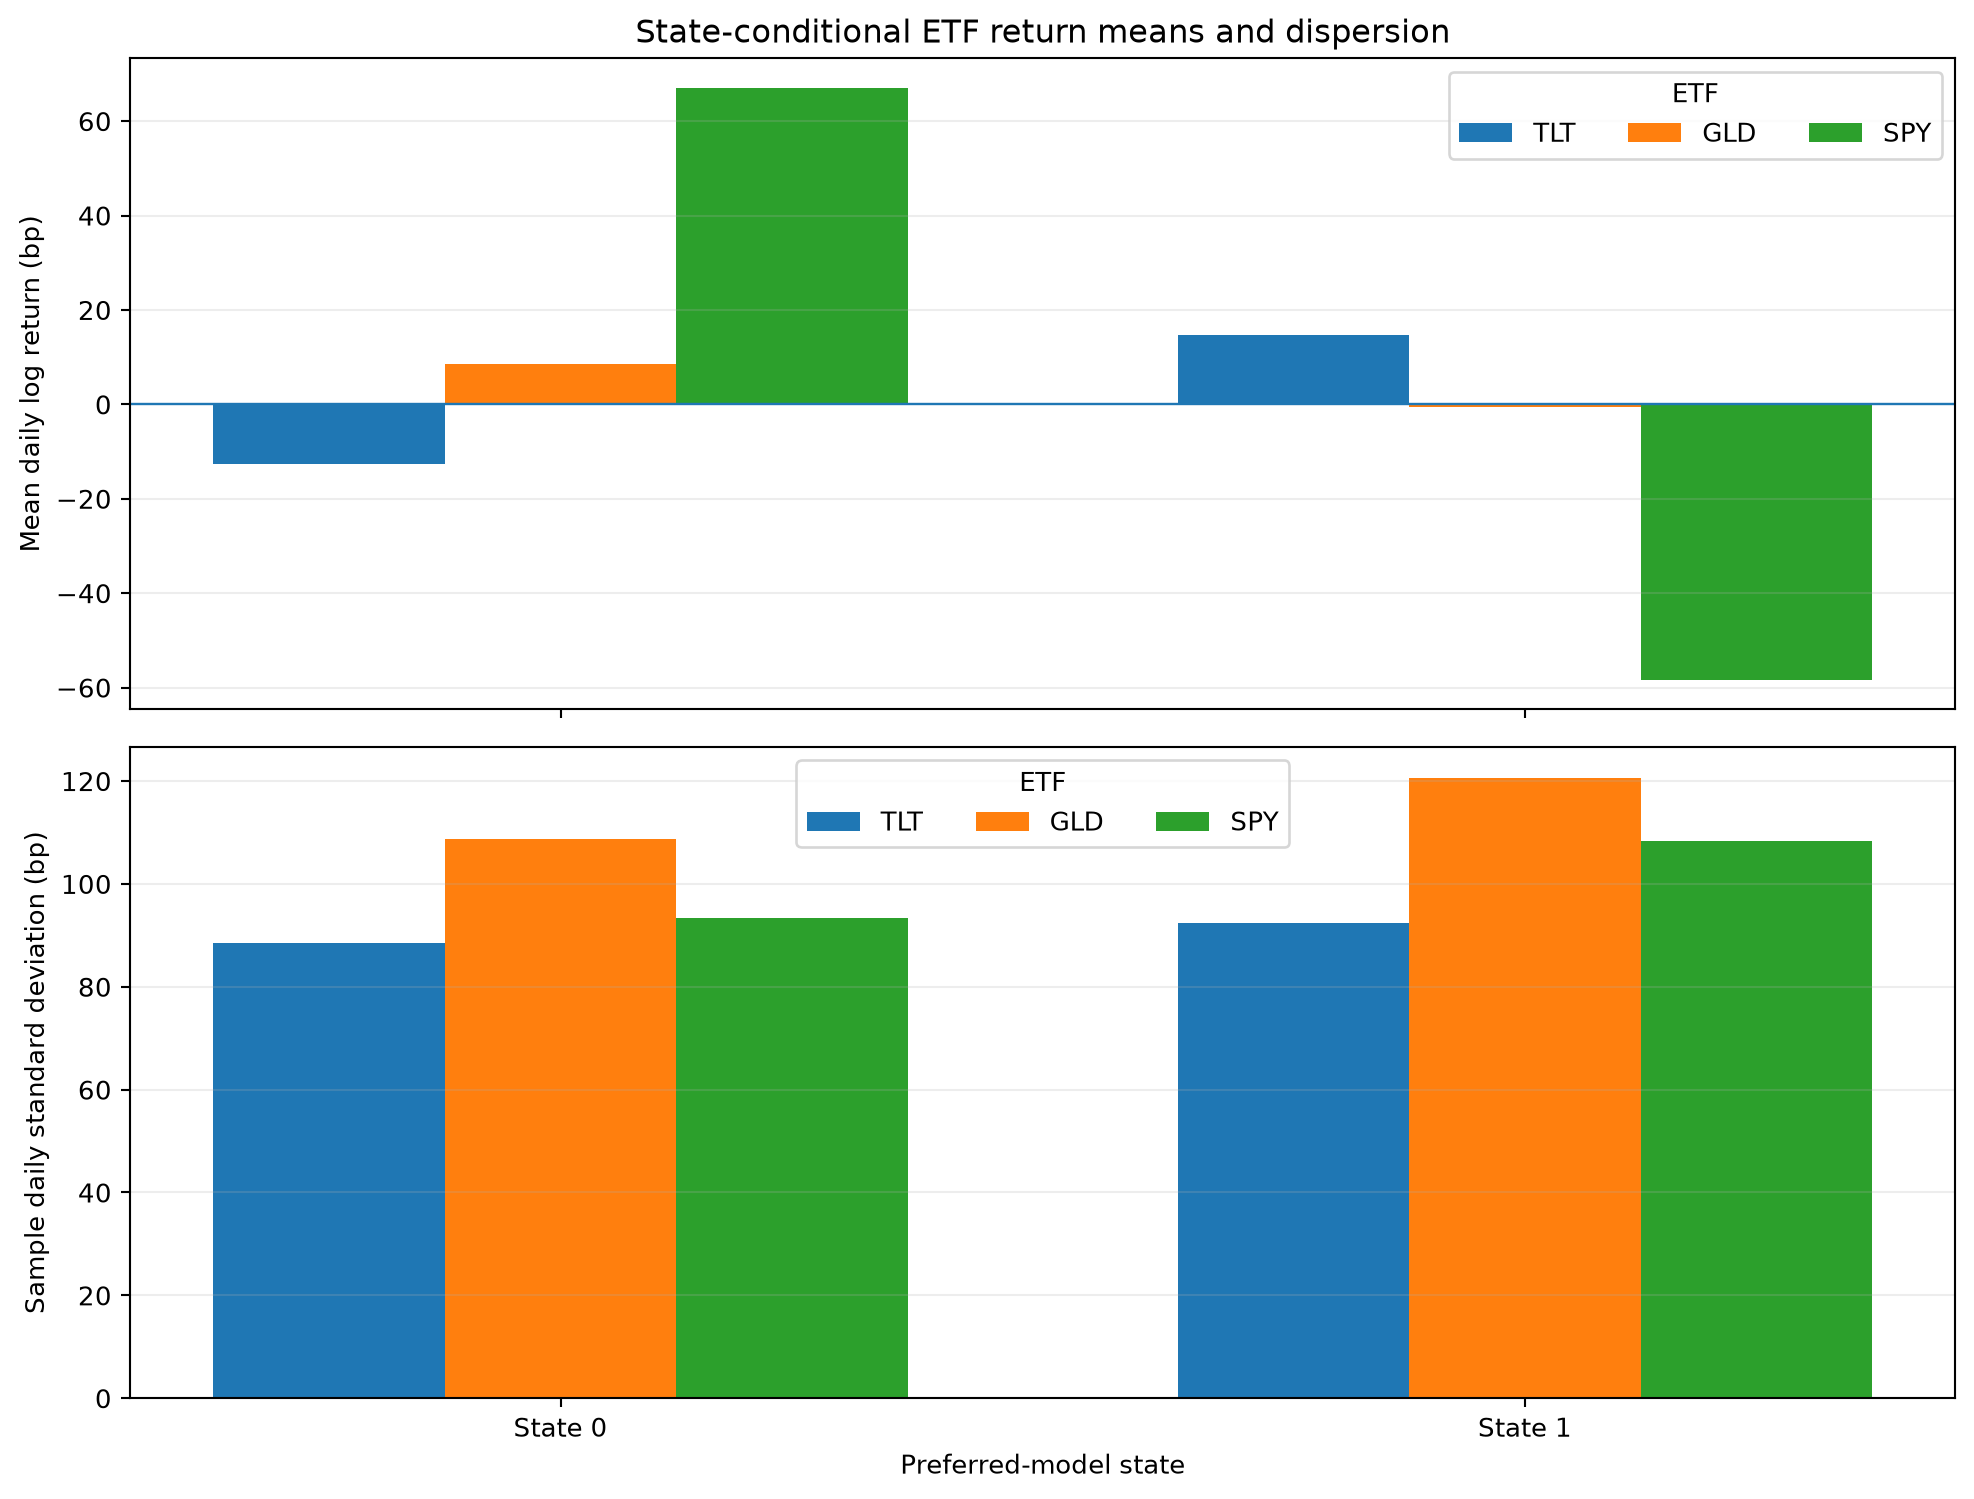

### Highest conditional mean daily log return in each state

,state,asset,mean_log_return,std_log_return,observations
0,0,SPY,0.006702,0.009337,2725
1,1,TLT,0.001478,0.009249,2740


In [11]:
nb.step_3_state_conditional_etf_analysis_023()


### Economic interpretation and limitations

The conditional table separates two distinct quantities that should not be conflated. The mean log return describes the average daily ETF outcome observed when the selected state was active, while the sample standard deviation describes how dispersed those daily outcomes were inside the same state. A higher conditional mean therefore does not by itself imply a superior risk-adjusted investment.

The displayed `state_leaders` table identifies the ETF with the highest **historical conditional mean daily log return** in each selected state. It is diagnostic evidence for the allocation rule used in Step 4; it is not yet the Step 4 allocation mapping and it does not execute trades.

Because the selected states and the conditional ETF means are estimated from the same full historical sample, this analysis is in-sample. In particular, selecting the asset with the largest full-sample conditional mean can introduce optimistic selection bias if the same mapping is subsequently evaluated on the same dates. The assignment's later one-day execution lag addresses same-day execution timing but does not remove this parameter-estimation look-ahead. A stronger research design would estimate regimes and conditional means using only information available before each decision date.

The numeric state labels remain neutral. State 0 and higher-numbered states are ordered by the selected model's daily `VIX_change` state definition; they are not automatically labels for low/high VIX levels, calm/crisis markets, or causal market environments.

**Source note.** Interpretation of the computed conditional statistics and limitations of the full-sample project design: project team.

## Step 4 — State-based rotation rule

The preferred Step 3 regime sequence is converted into a deterministic **state-to-ETF allocation map**. For each selected state, the strategy assigns 100% weight to the ETF with the largest historical mean daily log return in that state. The candidate assets are TLT, GLD, and SPY, and an exact equality is broken by the fixed priority **TLT → GLD → SPY**. The optional 60/40 variant is not used.

**Greek letters used in the following equations:** none.

For state $s$, let $ar r_{a,s}$ denote the historical mean daily log return of asset $a$. The selected asset is

$$
a_s^*=\operatorname*{arg\,max}_{a\in\{TLT,GLD,SPY\}}ar r_{a,s},
$$

with the fixed tie priority above, and the portfolio weights are

$$
w_{a,s}=egin{cases}1,&a=a_s^*,\0,&a
eq a_s^*.\end{cases}
$$

This is a project decision rule derived from the assignment rather than a claim that a maximum-mean, single-asset portfolio is generally optimal.

**Source note.** State-conditional ETF means: canonical Step 3 project artifact. Allocation rule, tie rule, and weights: project-team implementation of the assignment specification.

In [12]:
nb.step_4_state_based_rotation_rule_026()


### Canonical state-to-allocation mapping

,state,selected_asset,selection_mean_log_return,TLT_weight,GLD_weight,SPY_weight
0,0,SPY,0.006702,0.0,0.0,1.0
1,1,TLT,0.001478,1.0,0.0,0.0


### Interpretation, practical use, and limitations

For the selected two-state Markov specification, **State 0 allocates to SPY** because SPY has the largest historical conditional mean daily log return in that state, while **State 1 allocates to TLT** because TLT has the largest conditional mean in State 1. GLD is not selected by the maximum-mean rule in either state. These are descriptive, sample-dependent decisions; they are not claims that SPY or TLT will remain the best asset in the corresponding regime in future data.

The rule deliberately concentrates the portfolio in one asset and uses conditional mean return as the selection criterion. Classical portfolio theory emphasizes that portfolio choice should also account for risk and diversification rather than expected return alone (Markowitz 77–91). Therefore this rotation map should be interpreted as the assignment's transparent regime rule, not as a mean-variance-efficient allocation.

<!-- citekey: markowitz1952portfolio -->

The mapping is also **in-sample**. The regime thresholds/model parameters were estimated using the full analysis sample, the selected state sequence is a full-sample artifact, and the state-conditional ETF means used here are computed on that same sample. Step 5 will apply the assignment-required one-observed-trading-row execution lag, but that lag does not retroactively make the model estimation or allocation mapping causal or out-of-sample. A stronger validation would require rolling or expanding estimation, decision-time-only state inference, and decision-time-only allocation estimates.

**Source note.** State/ETF winners and weights: project-team calculations from the canonical Step 3 statistics. Risk/diversification limitation: Markowitz (1952). In-sample qualification: direct consequence of the project's full-sample estimation design.

## Step 5 — Backtest construction and required benchmarks

The backtest converts the ETF daily log returns to simple returns before portfolio arithmetic and applies the Step 4 allocation with an exact **one-observed-trading-row execution lag**. Therefore the state recorded on observed row $t-1$ determines the portfolio weights applied to ETF returns on observed row $t$. The first Step 1 row is excluded because no preceding observed regime decision exists.

**Greek letters used in the following equations:** none.

For an ETF log return $l_{a,t}$, the simple return is

$$
r_{a,t}=\exp(l_{a,t})-1.
$$

For the rotation portfolio,

$$
R^{\mathrm{rot}}_t=\sum_{a\in\{TLT,GLD,SPY\}} w_{a,S_{t-1}}r_{a,t}.
$$

The benchmark comparison uses exactly the same return dates as the lagged rotation. The equal-weight benchmark starts at one-third TLT, one-third GLD, and one-third SPY, resets to those weights immediately before the first comparison return and before the first observed comparison return in each new calendar month, and then allows weights to drift within the month. The second benchmark is SPY buy-and-hold. All reported backtest returns are **gross of transaction costs and taxes**, so the implemented cost assumption is zero.

The execution lag prevents using the same row's state to trade the same row's return, but it does **not** make the analysis causal or out-of-sample. Regime thresholds/model parameters and the preferred state path were derived from the full sample; if an HMM path were preferred, its Viterbi sequence would also use the full sequence; and the state-conditional allocation means are full-sample estimates. Data-snooping and repeated backtest selection can materially overstate apparent performance, so the results below are descriptive rather than evidence of live-trading profitability (White 1097–1126; Bailey and Lopez de Prado 94–107).

<!-- citekey: white2000datasnooping -->
<!-- citekey: bailey2014deflatedsharpe -->

**Source note.** Returns, state provenance, and the Step 4 allocation are canonical project artifacts. Lag/benchmark arithmetic is implemented by the project team. The non-out-of-sample qualification is supported by White (2000) and Bailey and Lopez de Prado (2014).

In [13]:
nb.step_5_backtest_construction_and_required_benchm_031()


### Lagged rotation decision examples

,decision_date,decision_state,selected_asset,TLT_weight,GLD_weight,SPY_weight,regime_rotation_return
Date,,,,,,,
2004-11-22,2004-11-19,1,TLT,1.0,0.0,0.0,0.005212
2004-11-23,2004-11-22,0,SPY,0.0,0.0,1.0,0.001526
2004-11-24,2004-11-23,0,SPY,0.0,0.0,1.0,0.002370
2004-11-26,2004-11-24,1,TLT,1.0,0.0,0.0,-0.006530
2004-11-29,2004-11-26,1,TLT,1.0,0.0,0.0,-0.010651
2004-11-30,2004-11-29,1,TLT,1.0,0.0,0.0,-0.004238
2004-12-01,2004-11-30,1,TLT,1.0,0.0,0.0,-0.001559
2004-12-02,2004-12-01,0,SPY,0.0,0.0,1.0,0.000839


### Canonical Step 5 daily comparison returns

,regime_rotation,equal_weight_monthly,spy_buy_hold
Date,,,
2004-11-22,0.005212,0.004592,0.004769
2004-11-23,0.001526,-0.000560,0.001526
2004-11-24,0.002370,0.003016,0.002370
2004-11-26,-0.006530,-0.000655,-0.000760
2004-11-29,-0.010651,-0.004237,-0.004563
2004-11-30,-0.004238,-0.003248,0.000679
2004-12-01,-0.001559,0.005190,0.011366
2004-12-02,0.000839,-0.004220,0.000839


Comparison period: **2004-11-22** to **2026-08-17**, observations: **5464**.

### Timing and benchmark interpretation

The displayed `decision_date` is the prior observed trading row for each realized rotation return. This makes the timing convention directly auditable: a regime switch only affects the next observed trading row. Missing calendar days are not synthetically created and no state is forward-filled across a non-trading row.

The equal-weight comparator is a **monthly-reset** portfolio, not a daily-reset portfolio. After a calendar-month reset, realized asset returns mechanically change the constituent weights until the next observed comparison date in a new month. SPY is evaluated on exactly the same dates, so all three daily-return series have identical sample sizes and date support.

These comparisons remain full-sample, gross-of-cost descriptive backtests. The one-row execution delay addresses same-row execution timing only; it does not remove the full-sample regime-estimation and allocation-selection look-ahead described above. A stronger validation would estimate regimes and state-conditional allocations using only information available at each decision date and would include implementation costs.

### Step 5 — Performance metrics and cumulative comparison

Performance is evaluated on the identical lagged comparison dates established above. The metric implementation uses simple daily portfolio returns, 252 trading days per year, a zero risk-free rate, sample volatility with denominator $n-1$, and initial wealth $W_0=1$.

**Greek letters used in the following equations:** none.

Wealth evolves as

$$
W_0=1,\qquad W_t=W_{t-1}(1+R_t).
$$

Cumulative return is

$$
R_{\mathrm{cum}}=W_n-1,
$$

and annualized return is

$$
R_{\mathrm{ann}}=W_n^{252/n}-1.
$$

With sample standard deviation

$$
s=\sqrt{\frac{1}{n-1}\sum_{t=1}^{n}(R_t-\bar R)^2},
$$

the annualized volatility and zero-risk-free Sharpe ratio are

$$
V_{\mathrm{ann}}=s\sqrt{252},\qquad
S=\frac{\bar R}{s}\sqrt{252}.
$$

Drawdown is measured relative to the running wealth peak **including the initial wealth observation**:

$$
D_t=\frac{W_t}{\max_{0\le u\le t}W_u}-1,\qquad
D_{\max}=\min_t D_t.
$$

The cumulative-performance figure uses the same shared compounding function as the metric table, so the plotted terminal values and the reported cumulative returns have one numerical source of truth. These project calculations follow standard portfolio-performance conventions and remain descriptive for this full-sample exercise.

In [14]:
nb.step_5_performance_metrics_and_cumulative_compar_034()


### Required performance summary

,portfolio,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,observations
0,regime_rotation,0.849021,0.028754,0.160369,0.257204,-0.537600,5464
1,equal_weight_monthly,5.420849,0.089548,0.097112,0.931856,-0.230437,5464
2,spy_buy_hold,8.798148,0.110994,0.188845,0.651956,-0.551894,5464


![Cumulative performance comparison](/home/runner/work/vix-regime-allocation/vix-regime-allocation/reports/figures/step5_cumulative_performance.png)

### Numerical comparison
- **Regime rotation:** cumulative return 0.849021; annualized return 0.028754; annualized volatility 0.160369; Sharpe 0.257204; maximum drawdown -0.537600; observations 5464.
- **Equal-weight monthly reset:** cumulative return 5.420849; annualized return 0.089548; annualized volatility 0.097112; Sharpe 0.931856; maximum drawdown -0.230437; observations 5464.
- **SPY buy and hold:** cumulative return 8.798148; annualized return 0.110994; annualized volatility 0.188845; Sharpe 0.651956; maximum drawdown -0.551894; observations 5464.

### Interpretation of the performance comparison

The table and figure should be read jointly: cumulative and annualized return describe growth, annualized volatility and maximum drawdown describe different dimensions of risk, and the Sharpe ratio summarizes average return per unit of daily return dispersion under the assignment's zero-risk-free convention. The comparison covers both required benchmarks on identical dates.

The same full-sample qualification stated above remains binding for every value in this section. The one-row execution lag removes same-row trading, but it does not undo full-sample regime estimation or the use of full-sample state-conditional means in the allocation rule. Consequently, the reported risk-adjusted comparison is descriptive and in-sample rather than causal or out-of-sample evidence.

## Works Cited

The following MLA 9 entries are rendered programmatically from the cited keys in the canonical `reports/references.bib` registry.

In [15]:
nb.works_cited_037()


- Whaley, Robert E.. "Understanding the VIX." *The Journal of Portfolio Management*, vol. 35, no. 3, 2009, pp. 98-105. doi:10.3905/JPM.2009.35.3.098.
- Cboe Global Markets. "Cboe VIX FAQ." *Cboe Global Markets*, 2019, https://www.cboe.com/tradable_products/vix/faqs. Accessed 19 Aug. 2026.
- Baum, Leonard E., et al.. "A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains." *The Annals of Mathematical Statistics*, vol. 41, no. 1, 1970, pp. 164-171. doi:10.1214/aoms/1177697196.
- Rabiner, Lawrence R.. "A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition." *Proceedings of the IEEE*, vol. 77, no. 2, 1989, pp. 257-286. doi:10.1109/5.18626.
- Viterbi, Andrew J.. "Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm." *IEEE Transactions on Information Theory*, vol. 13, no. 2, 1967, pp. 260-269. doi:10.1109/TIT.1967.1054010.
- Akaike, Hirotugu. "A New Look at the Statistical Model Identification." *IEEE Transactions on Automatic Control*, vol. 19, no. 6, 1974, pp. 716-723. doi:10.1109/TAC.1974.1100705.
- Schwarz, Gideon. "Estimating the Dimension of a Model." *The Annals of Statistics*, vol. 6, no. 2, 1978, pp. 461-464. doi:10.1214/aos/1176344136.
- Markowitz, Harry. "Portfolio Selection." *The Journal of Finance*, vol. 7, no. 1, 1952, pp. 77-91. doi:10.1111/j.1540-6261.1952.tb01525.x.
- White, Halbert. "A Reality Check for Data Snooping." *Econometrica*, vol. 68, no. 5, 2000, pp. 1097-1126. doi:10.1111/1468-0262.00152.
- Bailey, David H.. "The Deflated Sharpe Ratio: Correcting for Selection Bias, Backtest Overfitting, and Non-Normality." *The Journal of Portfolio Management*, vol. 40, no. 5, 2014, pp. 94-107. doi:10.3905/jpm.2014.40.5.094.